# Feature Selection — keep the columns that matter

> 📘 **Instructor Curriculum** — Session 23.

## The story

Kavya works at a breast-cancer screening lab. For every tumour, a scan gives
30 numbers: its radius, its texture, its area, and so on. She has 569 tumours,
and a doctor has already marked each one as cancer or not cancer.

She wants to train a model, but she does not want to give it all 30 columns.
Her first idea was simple: look at the table and keep the columns with big
numbers.

That does not work. `mean area` is around 1000 and `mean smoothness` is around
0.1. The size of a number only tells you its unit. It does not tell you if the
column helps. And some columns are the same thing measured twice: radius,
perimeter and area all measure how big the tumour is.

So she needs a rule, not a guess. This notebook tries three rules:

| Rule | The question it asks |
|---|---|
| 1. Mutual information | How much does this column tell me about the answer? |
| 2. Correlation | Does this column just repeat another column? |
| 3. Variance threshold | Does this column change at all? |

All three look only at the data. None of them trains a model. (Forward and
backward selection, in notebooks 20 and 22, train a model to test each column.)

In [4]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

In [5]:
data = load_breast_cancer()

In [2]:
from sklearn.feature_selection import mutual_info_classif
import matplotlib.pyplot as plt
import pandas as pd

In [4]:
table = pd.DataFrame(data.data,columns=data.feature_names)
table.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [5]:
table.shape

(569, 30)

## The data

`load_breast_cancer()` is a dataset that comes with scikit-learn. We use three
parts of it:

- `data.data` — the numbers, 569 rows × 30 columns
- `data.target` — the answer for each row: `0` = cancer (malignant, 212 rows),
  `1` = not cancer (benign, 357 rows)
- `data.feature_names` — the 30 column names

`table` is the same numbers in a DataFrame, so the columns have names.

The 30 columns are really 10 measurements, each stored three ways: `mean`
(the average), `error` (how much it varies), and `worst` (the largest value).

## Rule 1 — Mutual information

Mutual information asks one question per column: **if I know this column, how much does it tell me about the answer?**

Think of each feature as a clue in Kavya's screening report. If knowing a clue makes the cancer/not-cancer decision easier, that clue contains information about the target. If the clue looks unrelated to the diagnosis, it contains little useful information.

- `0` means the feature and the target show no detectable relationship in this data.
- A larger score means the feature gives more information about the target.
- The score is not an accuracy percentage, and it is not a probability that the feature is important.
- Mutual information can detect both straight-line relationships and more complicated relationships, so it is more flexible than checking only ordinary correlation.

### What goes into the function?

`mutual_info_classif(X, y)` needs two matching inputs:

- `X` — the feature table. Here it is `data.data`, with shape `(569, 30)`: 569 tumours and 30 candidate columns.
- `y` — the target, here `data.target`, with shape `(569,)`: one cancer/not-cancer label for each tumour.

The function examines each of the 30 columns in `X` against the corresponding labels in `y`. It returns one score per column, so the result has shape `(30,)`. The first score belongs to `mean radius`, the second to `mean texture`, and so on in `data.feature_names` order.

### A small example

Suppose a feature is `tumour size`:

- if small tumours are usually benign and large tumours are usually malignant, knowing size helps us guess the target, so its score should be relatively high;
- if the feature is `scanner serial number`, knowing it should not help us decide the diagnosis, so its score should be close to zero.

The score does **not** prove that a feature causes cancer. It only measures how much the observed feature values and target labels are related in this dataset. It can also be noisy, especially with small datasets, so we should use it to rank candidates rather than treat one score as final truth.

The next code cell calculates these 30 scores. The cell after that will attach the feature names, sort the scores, and show which clues appear most useful.

## Before we calculate: see the question

Before asking scikit-learn for a score, let us draw the same question with a tiny screening report. Each dot is one tumour, the horizontal axis is one feature, and the colour is the known target:

- **blue = benign** (`target = 1`)
- **red = malignant** (`target = 0`)

A useful feature makes the colours form different regions. An unhelpful feature leaves the colours mixed together. Mutual information gives a larger score to the first situation because knowing the feature value makes the target easier to guess.

For this small demonstration we will put tumour size into three bins: **small**, **medium**, and **large**. Then we can count how often each size bin appears with each diagnosis. That count table is the part the formula uses.

We will compare it with a **scanner group**, not a unique scanner ID. A unique ID is dangerous for this demonstration: because every row has a different number, it can identify the row itself and appear informative even when it has no medical meaning. Real feature selection must always question whether a high score represents useful signal or an accidental identifier.

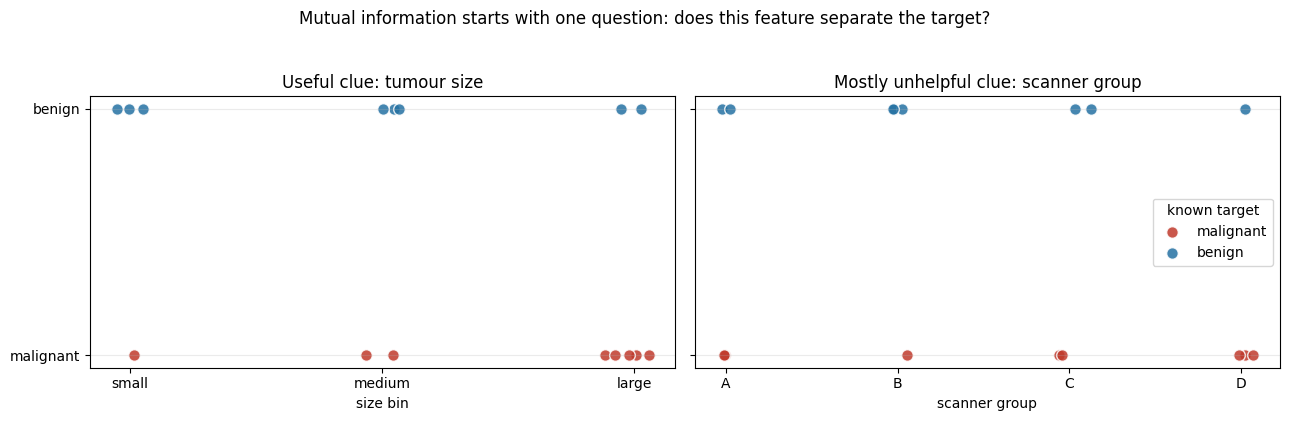

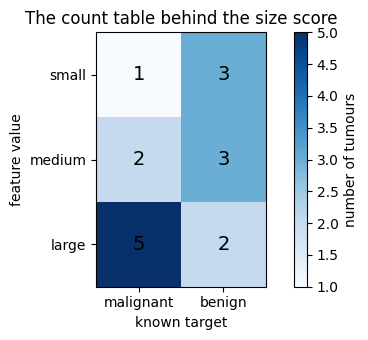

Mutual information for tumour size: 0.116 bits
Mutual information for scanner group: 0.094 bits


In [8]:
import numpy as np

# A tiny, deliberately simple screening report: 0 = malignant, 1 = benign.
size_bin = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2])
target_demo = np.array([1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1])
scanner_group = np.array([0, 1, 2, 3, 0, 1, 2, 3, 1, 0, 3, 2, 2, 3, 0, 1])
size_labels = ['small', 'medium', 'large']
target_labels = ['malignant', 'benign']

# For a discrete example, this is the mutual-information formula directly.
def discrete_mutual_information(feature, target):
    total = len(feature)
    score = 0.0
    for feature_value in np.unique(feature):
        for target_value in np.unique(target):
            joint_count = np.sum((feature == feature_value) & (target == target_value))
            if joint_count == 0:
                continue
            joint_probability = joint_count / total
            feature_probability = np.sum(feature == feature_value) / total
            target_probability = np.sum(target == target_value) / total
            score += joint_probability * np.log2(
                joint_probability / (feature_probability * target_probability)
            )
    return score

size_mi = discrete_mutual_information(size_bin, target_demo)
scanner_mi = discrete_mutual_information(scanner_group, target_demo)
rng = np.random.default_rng(42)

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
colors = {0: '#c0392b', 1: '#2471a3'}
for axis, feature, title, x_label in [
    (axes[0], size_bin, 'Useful clue: tumour size', 'size bin'),
    (axes[1], scanner_group, 'Mostly unhelpful clue: scanner group', 'scanner group'),
]:
    for target_value in [0, 1]:
        selected = target_demo == target_value
        jitter = rng.normal(0, 0.06, np.sum(selected))
        axis.scatter(
            feature[selected] + jitter,
            target_demo[selected],
            color=colors[target_value],
            label=target_labels[target_value],
            s=70,
            alpha=0.85,
            edgecolor='white',
        )
    axis.set_title(title)
    axis.set_xlabel(x_label)
    axis.set_yticks([0, 1], ['malignant', 'benign'])
    axis.grid(axis='y', alpha=0.25)
axes[0].set_xticks([0, 1, 2], size_labels)
axes[1].set_xticks([0, 1, 2, 3], ['A', 'B', 'C', 'D'])
axes[1].legend(title='known target')
fig.suptitle('Mutual information starts with one question: does this feature separate the target?', y=1.04)
plt.tight_layout()
plt.show()

# Count how many tumours fall into each (size bin, diagnosis) combination.
counts = np.zeros((3, 2), dtype=int)
for feature_value in range(3):
    for target_value in range(2):
        counts[feature_value, target_value] = np.sum(
            (size_bin == feature_value) & (target_demo == target_value)
        )

fig, axis = plt.subplots(figsize=(6, 3.5))
image = axis.imshow(counts, cmap='Blues')
axis.set_title('The count table behind the size score')
axis.set_xlabel('known target')
axis.set_ylabel('feature value')
axis.set_xticks([0, 1], target_labels)
axis.set_yticks([0, 1, 2], size_labels)
for row in range(counts.shape[0]):
    for column in range(counts.shape[1]):
        axis.text(column, row, counts[row, column], ha='center', va='center', fontsize=14)
fig.colorbar(image, ax=axis, label='number of tumours')
plt.tight_layout()
plt.show()

print(f'Mutual information for tumour size: {size_mi:.3f} bits')
print(f'Mutual information for scanner group: {scanner_mi:.3f} bits')

## What the visual calculation is showing

👀 **Look at the left plot first.** The tumour-size values move from small to large. The red malignant dots become more common toward the large end, while blue benign dots are more common toward the small and medium ends. Knowing the size therefore changes our expectation about the diagnosis. That is why its mutual-information score is higher.

👀 **Now look at the right plot.** Each scanner group contains a mixture of red and blue dots. Knowing the group does not make the diagnosis much easier to guess, so its score is lower. The colours are not perfectly mixed because this is a tiny sample; mutual information measures the relationship actually observed, not the relationship we hoped to create.

### How one part of the formula is calculated

For the `small` + `benign` square in the count table:

- joint count = `3`, so $p(\text{small}, \text{benign}) = 3/16$
- small count = `4`, so $p(\text{small}) = 4/16$
- benign count = `8`, so $p(\text{benign}) = 8/16$

Mutual information adds one contribution for every non-empty square:

$$
I(X;Y) = \sum_{x,y} p(x,y)\log_2\left(\frac{p(x,y)}{p(x)p(y)}\right)
$$

For this one square:

$$
\frac{3}{16}\log_2\left(\frac{3/16}{(4/16)(8/16)}\right)
= \frac{3}{16}\log_2(1.5) \approx 0.110 \text{ bits}
$$

We repeat that calculation for all six squares in the heatmap and add the contributions. The total for this toy tumour-size feature is `0.116 bits`. A score of zero would mean the joint counts look exactly like we would expect if feature and target were unrelated.

This toy calculation uses discrete bins so we can see every count. The real dataset contains continuous measurements, so `mutual_info_classif` estimates the same idea from the numeric values. It returns one estimated score for each of the 30 real features, which the next code cell calculates.

In [9]:
imp = mutual_info_classif(data.data, data.target)

In [7]:
fimp = pd.Series(imp,table.columns[0:len(table.columns)])
fimp.sort_values(ascending=False)

worst perimeter            0.476609
worst area                 0.463210
worst radius               0.452496
mean concave points        0.439315
worst concave points       0.437874
mean perimeter             0.403214
mean concavity             0.374832
mean radius                0.364263
mean area                  0.360122
area error                 0.340625
worst concavity            0.316958
perimeter error            0.273136
radius error               0.249299
worst compactness          0.226720
mean compactness           0.213611
concave points error       0.125179
worst texture              0.123267
concavity error            0.117122
mean texture               0.099861
worst smoothness           0.097346
worst symmetry             0.092600
mean smoothness            0.081944
compactness error          0.075217
worst fractal dimension    0.068899
mean symmetry              0.064848
fractal dimension error    0.038395
smoothness error           0.016374
symmetry error             0

The top and the bottom of the list:

| Column | Score | Meaning |
|---|---|---|
| worst perimeter | about 0.47 | tells a lot |
| worst area | about 0.46 | tells a lot |
| worst radius | about 0.45 | tells a lot |
| … | | |
| mean fractal dimension | close to 0 | tells almost nothing |
| texture error | close to 0 | tells almost nothing |

The top three all measure size. That matches the simple example above.

The scores move a little each time you run the cell, because they are an
estimate. The order at the top stays the same.

<function matplotlib.pyplot.show(close=None, block=None)>

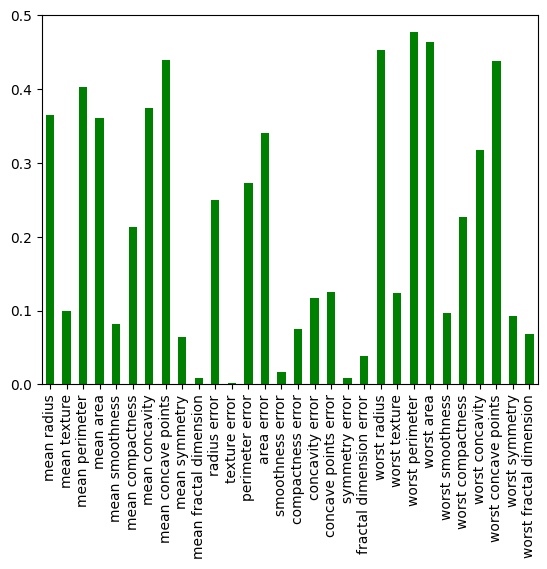

In [8]:
fimp.plot(kind='bar',color='green')
plt.show

The same scores as bars. The bars are in the original column order, not
sorted: `sort_values()` in the cell above printed a sorted copy, but it did not
change `fimp`. The tallest bars are the `worst` size columns on the right.

## Rule 2 — Correlation

Correlation compares two columns and gives a number from -1 to 1.

- Near `1`: when one goes up, the other goes up too. They say the same thing.
- Near `0`: they are not linked.

`table.corr()` does this for every pair of columns, so `matrix` is a 30 × 30
table.

Simple example from `matrix`: `mean radius` and `mean perimeter` have a
correlation of `0.998`. That makes sense, because perimeter = 2 × π × radius.
If you know one, you know the other. The model needs only one of them.

Correlation does not look at the answer `y`. It only compares columns with
each other.

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

In [10]:
matrix = table.corr()

In [11]:
matrix

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
mean radius,1.000000,0.323782,0.997855,0.987357,0.170581,0.506124,0.676764,0.822529,0.147741,-0.311631,...,0.969539,0.297008,0.965137,0.941082,0.119616,0.413463,0.526911,0.744214,0.163953,0.007066
mean texture,0.323782,1.000000,0.329533,0.321086,-0.023389,0.236702,0.302418,0.293464,0.071401,-0.076437,...,0.352573,0.912045,0.358040,0.343546,0.077503,0.277830,0.301025,0.295316,0.105008,0.119205
mean perimeter,0.997855,0.329533,1.000000,0.986507,0.207278,0.556936,0.716136,0.850977,0.183027,-0.261477,...,0.969476,0.303038,0.970387,0.941550,0.150549,0.455774,0.563879,0.771241,0.189115,0.051019
mean area,0.987357,0.321086,0.986507,1.000000,0.177028,0.498502,0.685983,0.823269,0.151293,-0.283110,...,0.962746,0.287489,0.959120,0.959213,0.123523,0.390410,0.512606,0.722017,0.143570,0.003738
mean smoothness,0.170581,-0.023389,0.207278,0.177028,1.000000,0.659123,0.521984,0.553695,0.557775,0.584792,...,0.213120,0.036072,0.238853,0.206718,0.805324,0.472468,0.434926,0.503053,0.394309,0.499316
mean compactness,0.506124,0.236702,0.556936,0.498502,0.659123,1.000000,0.883121,0.831135,0.602641,0.565369,...,0.535315,0.248133,0.590210,0.509604,0.565541,0.865809,0.816275,0.815573,0.510223,0.687382
mean concavity,0.676764,0.302418,0.716136,0.685983,0.521984,0.883121,1.000000,0.921391,0.500667,0.336783,...,0.688236,0.299879,0.729565,0.675987,0.448822,0.754968,0.884103,0.861323,0.409464,0.514930
mean concave points,0.822529,0.293464,0.850977,0.823269,0.553695,0.831135,0.921391,1.000000,0.462497,0.166917,...,0.830318,0.292752,0.855923,0.809630,0.452753,0.667454,0.752399,0.910155,0.375744,0.368661
mean symmetry,0.147741,0.071401,0.183027,0.151293,0.557775,0.602641,0.500667,0.462497,1.000000,0.479921,...,0.185728,0.090651,0.219169,0.177193,0.426675,0.473200,0.433721,0.430297,0.699826,0.438413
mean fractal dimension,-0.311631,-0.076437,-0.261477,-0.283110,0.584792,0.565369,0.336783,0.166917,0.479921,1.000000,...,-0.253691,-0.051269,-0.205151,-0.231854,0.504942,0.458798,0.346234,0.175325,0.334019,0.767297


<Axes: >

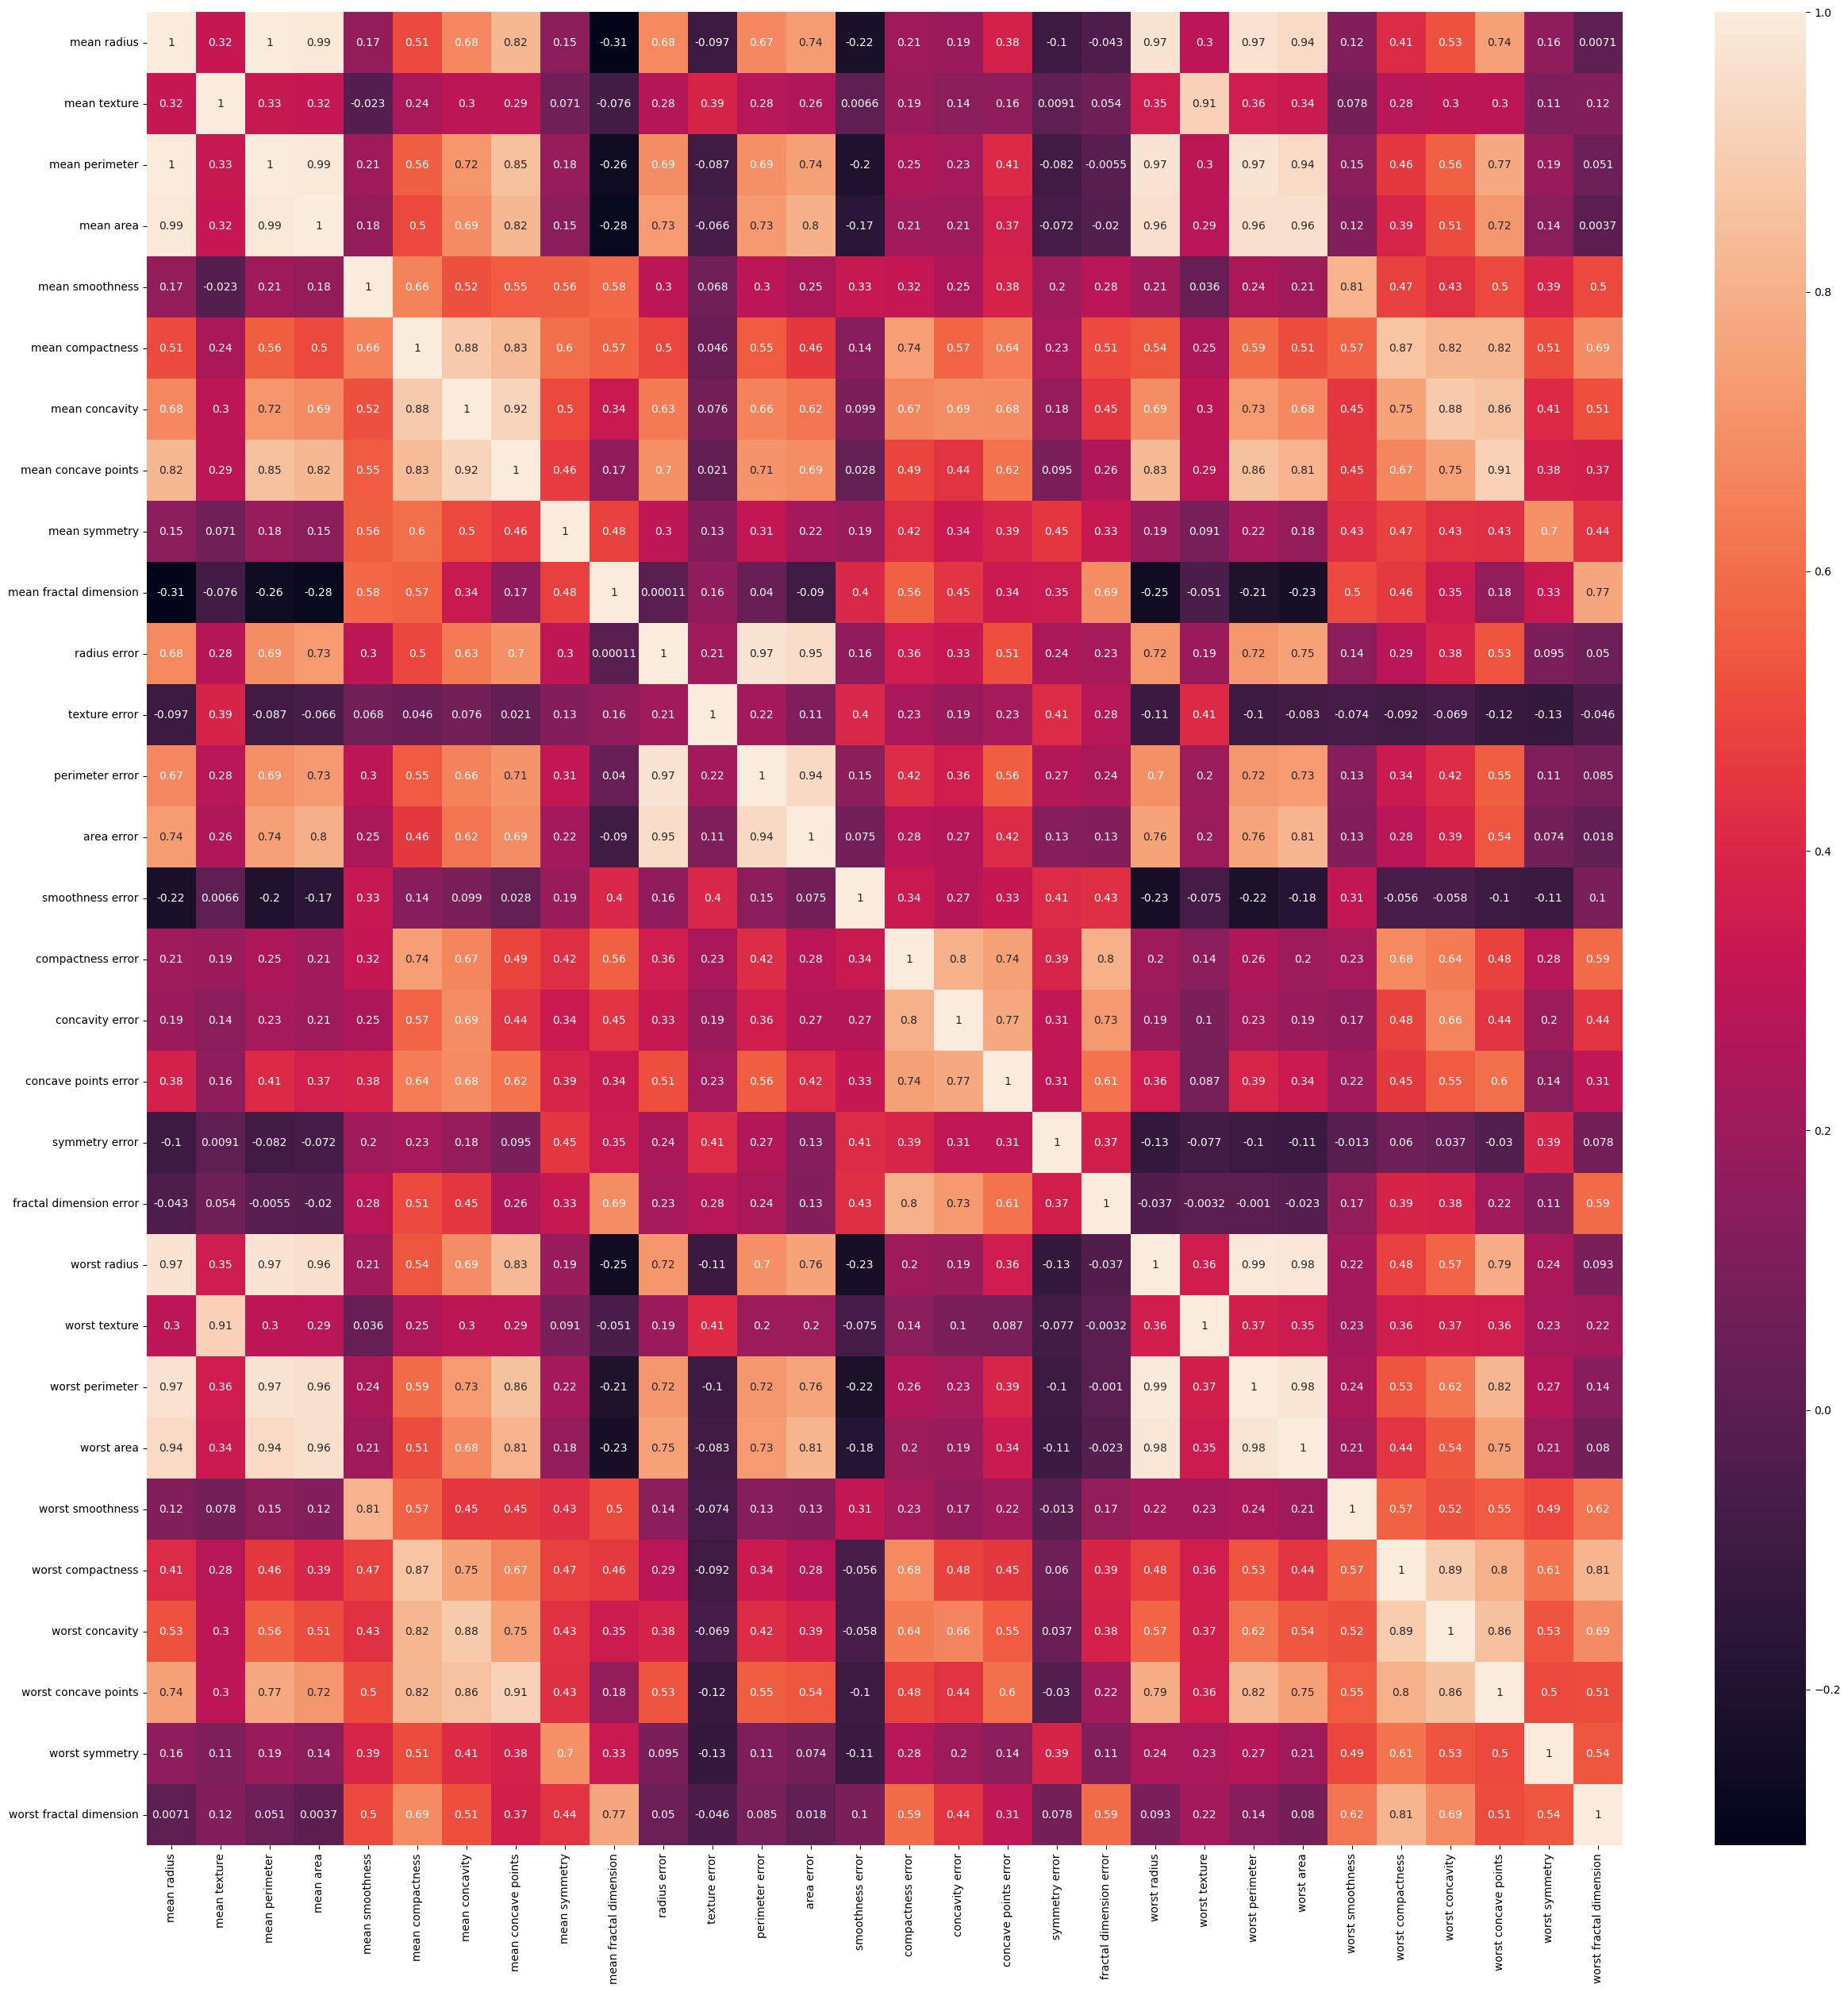

In [12]:
plt.figure(figsize = (30,30))
sns.heatmap(matrix,annot = True)

The heatmap draws `matrix` as colours. Light squares are close to 1. The
diagonal is always 1, because every column matches itself. The light blocks
are groups of columns that repeat each other, like radius, perimeter and
area.

### Finding the columns to drop

The loop checks every pair of columns once.

- `i` is a column, and `j` is every column **before** it (`range(i)`). So each
  pair is checked only one time.
- If the pair's correlation is above `0.9`, column `i` (the later one) goes into
  `final`.
- `final` is a `set`, so a column goes in only once, even if it repeats several
  columns.

Example: `mean radius` is column 0 and `mean perimeter` is column 2. When
`i = 2` and `j = 0`, the value is `0.998`, so `mean perimeter` goes into
`final`.

In [13]:
final = set()
for i in range(len(matrix.columns)):
        for j in range(i):
            if matrix.iloc[i, j] > 0.9: 
                col_name = matrix.columns[i]  
                final.add(col_name)

In [14]:
final

{'area error',
 'mean area',
 'mean concave points',
 'mean perimeter',
 'perimeter error',
 'worst area',
 'worst concave points',
 'worst perimeter',
 'worst radius',
 'worst texture'}

10 columns are in `final`. Each one repeats a column that comes before it:

| Column to drop | Repeats | Correlation |
|---|---|---|
| mean perimeter | mean radius | 0.998 |
| mean area | mean radius | 0.987 |
| mean concave points | mean concavity | 0.921 |
| perimeter error | radius error | 0.973 |
| area error | radius error | 0.952 |
| worst radius | mean radius | 0.970 |
| worst texture | mean texture | 0.912 |
| worst perimeter | mean radius | 0.965 |
| worst area | mean radius | 0.941 |
| worst concave points | mean concave points | 0.910 |

Drop these 10 and keep the other 20.

`worst perimeter`, `worst area` and `worst radius` were the top three in Rule 1,
and they are dropped here. That is fine: `mean radius` stays, and it carries the
same size information.

## Why calculate `x1` and `x2` by hand first?

Before using `VarianceThreshold`, we calculate two tiny columns ourselves so the library does not feel like a black box.

- `x1` changes from row to row. By calculating its mean, deviations, squared deviations, and final variance, we can see exactly what **variation** means.
- `x2` is always `1`. Its calculation shows the opposite case: every value is equal to the mean, so every deviation is `0` and its variance is `0`.
- Comparing `x1` and `x2` gives us a simple mental picture: **changing column = variance above zero; constant column = variance of zero**.
- Once we understand that number, `VarianceThreshold(threshold=0.5)` becomes easy to read: it calculates the variance of every real feature and keeps only the columns whose variance is at least `0.5`.

So the hand calculation is not a separate exercise. It prepares us to understand what `VarianceThreshold` is calculating, why `x2` should be removed, and why the choice of threshold changes which columns survive. The next section works through the formula carefully, then the sklearn code performs the same kind of calculation across all 30 breast-cancer features.

## Rule 3 — Variance threshold

Variance answers this question: **how much does one column change from row to row?**

A column that has exactly the same value in every row has no variation. It cannot help us distinguish one row from another, so its variance is `0`.

### The formula we will use

For this feature-selection example, we use **population variance**:

$$
\operatorname{Var}(X) = \frac{1}{n}\sum_{i=1}^{n}(x_i - \bar{x})^2
$$

Read the symbols from left to right:

- $X$ — one feature column, such as `x1`.
- $n$ — the number of values in that column. Here, $n = 10$.
- $x_i$ — one value from the column.
- $\bar{x}$ — the mean, or average, of all values.
- $x_i - \bar{x}$ — how far one value is from the mean. This can be negative or positive.
- $(x_i - \bar{x})^2$ — the squared distance. Squaring removes negative signs and gives larger differences more weight.
- $\sum$ — add all the squared distances.
- Divide by $n$ — calculate the average squared distance.

### Complete calculation for `x1`

```text
x1 = [3, 5, 6, 7, 3, 4, 8, 9, 5, 1]
```

**Step 1 — Calculate the mean:**

$$
\bar{x}_1 = \frac{3+5+6+7+3+4+8+9+5+1}{10}
= \frac{51}{10} = 5.1
$$

**Step 2 — Calculate each deviation and square it:**

| Value $x_i$ | Deviation $x_i - 5.1$ | Squared deviation $(x_i - 5.1)^2$ |
|---:|---:|---:|
| 3 | -2.1 | 4.41 |
| 5 | -0.1 | 0.01 |
| 6 | 0.9 | 0.81 |
| 7 | 1.9 | 3.61 |
| 3 | -2.1 | 4.41 |
| 4 | -1.1 | 1.21 |
| 8 | 2.9 | 8.41 |
| 9 | 3.9 | 15.21 |
| 5 | -0.1 | 0.01 |
| 1 | -4.1 | 16.81 |
| **Total** | — | **54.90** |

**Step 3 — Divide the total squared distance by the number of values:**

$$
\operatorname{Var}(x1) = \frac{54.90}{10} = 5.49
$$

So `x1` changes noticeably from row to row, and its population variance is **5.49**.

### Complete calculation for `x2`

```text
x2 = [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
```

**Step 1 — Calculate the mean:**

$$
\bar{x}_2 = \frac{1+1+1+1+1+1+1+1+1+1}{10}
= \frac{10}{10} = 1
$$

**Step 2 — Calculate the deviations:** every value is $1$, so every deviation is:

$$
1 - 1 = 0
$$

Every squared deviation is therefore $0^2 = 0$.

**Step 3 — Calculate the variance:**

$$
\operatorname{Var}(x2) = \frac{0+0+0+0+0+0+0+0+0+0}{10} = 0
$$

So `x2` never changes. Its variance is **0**, which makes it a good candidate for removal.

> **Important:** dividing by $n$ gives population variance, which is what `VarianceThreshold` uses. In statistics, sample variance divides by $n-1$ when estimating the variance of a larger population. For `x1`, that would be $54.90 / 9 = 6.10$, but that is not the value used by `VarianceThreshold` here.

A variance threshold drops every column whose variance is below a number you choose. The next cells calculate these values and then apply the idea to the 30 breast-cancer features.

In [10]:
x1 = [3, 5, 6, 7, 3, 4, 8, 9, 5, 1]
x2 = [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

x1_mean = sum(x1) / len(x1)
x2_mean = sum(x2) / len(x2)
x1_squared_deviations = [(value - x1_mean) ** 2 for value in x1]
x2_squared_deviations = [(value - x2_mean) ** 2 for value in x2]

print(f'x1 mean: {x1_mean}')
print(f'x1 squared deviations: {x1_squared_deviations}')
print(f'x1 variance: {sum(x1_squared_deviations) / len(x1)}')
print(f'x2 mean: {x2_mean}')
print(f'x2 squared deviations: {x2_squared_deviations}')
print(f'x2 variance: {sum(x2_squared_deviations) / len(x2)}')

x1 mean: 5.1
x1 squared deviations: [4.409999999999998, 0.009999999999999929, 0.8100000000000006, 3.610000000000001, 4.409999999999998, 1.2099999999999993, 8.410000000000002, 15.210000000000003, 0.009999999999999929, 16.81]
x1 variance: 5.49
x2 mean: 1.0
x2 squared deviations: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
x2 variance: 0.0


## What will `VarianceThreshold` select?

Now connect the hand calculation to the real feature-selection operation.

`VarianceThreshold` does **not** select individual values from `x1`. It looks at the complete column and asks whether that column changes enough across all rows.

For our two example columns:

| Column | Variance | With `threshold=0.5` | Decision |
|---|---:|---|---|
| `x1` | `5.49` | `5.49 >= 0.5` | Keep the complete `x1` column |
| `x2` | `0.00` | `0.00 < 0.5` | Drop the complete `x2` column |

So if `X = [x1, x2]`, the selector keeps the `x1` feature, including all 10 of its row values, and removes the `x2` feature, including all 10 of its row values. It does not keep only the values `8` or `9` from `x1`; the decision is made for the whole column.

For the breast-cancer dataset, `X = data.data` has shape `(569, 30)`:

- 569 rows = 569 tumour records.
- 30 columns = 30 candidate features.
- `VarianceThreshold(threshold=0.5)` calculates one variance for each of the 30 columns.
- Every column with variance at least `0.5` is kept with all 569 row values.
- Every column with variance below `0.5` is removed completely.

In this notebook, 10 complete feature columns pass the threshold and 20 complete feature columns are removed. The next cell imports the sklearn class that performs this column-level filtering.

In [16]:
from sklearn.feature_selection import VarianceThreshold

`VarianceThreshold(threshold=0.5)` drops every column whose variance is below
0.5. `fit_transform` works out each column's variance and returns only the
columns it kept.

In [17]:
sel = VarianceThreshold(threshold=0.5)
sel.fit_transform(data.data)

array([[  17.99,   10.38,  122.8 , ...,   17.33,  184.6 , 2019.  ],
       [  20.57,   17.77,  132.9 , ...,   23.41,  158.8 , 1956.  ],
       [  19.69,   21.25,  130.  , ...,   25.53,  152.5 , 1709.  ],
       ...,
       [  16.6 ,   28.08,  108.3 , ...,   34.12,  126.7 , 1124.  ],
       [  20.6 ,   29.33,  140.1 , ...,   39.42,  184.6 , 1821.  ],
       [   7.76,   24.54,   47.92, ...,   30.37,   59.16,  268.6 ]],
      shape=(569, 10))

In [18]:
sel.get_support()

array([ True,  True,  True,  True, False, False, False, False, False,
       False, False, False,  True,  True, False, False, False, False,
       False, False,  True,  True,  True,  True, False, False, False,
       False, False, False])

`get_support()` gives one `True`/`False` per column. `True` means kept. 10 columns
are kept and 20 are dropped.

In [19]:
sel.get_feature_names_out()

array(['x0', 'x1', 'x2', 'x3', 'x12', 'x13', 'x20', 'x21', 'x22', 'x23'],
      dtype=object)

The names come out as `x0`, `x1`, … because `data.data` is a plain NumPy array
with no column names. `x0` means column 0. Pass `table` instead of `data.data`
and you get the real names.

The 10 kept columns, with their variance (`sel.variances_`):

| Kept column | Variance |
|---|---|
| worst area | 323 598 |
| mean area | 123 626 |
| area error | 2 066 |
| worst perimeter | 1 127 |
| mean perimeter | 589 |
| worst texture | 37.7 |
| worst radius | 23.3 |
| mean texture | 18.5 |
| mean radius | 12.4 |
| perimeter error | 4.1 |

### This is Kavya's first mistake again

Every kept column is measured in big numbers. Areas are in the hundreds, so
their variance is huge. The dropped columns are measured in small numbers, like
`mean concave points`, whose variance is `0.0015`.

But `mean concave points` was 4th in Rule 1 (score about 0.44). It is a useful
column, and the threshold dropped it only because its unit is small.

So with a threshold above 0 on raw data, variance mostly measures the **unit**,
not how useful the column is. The safe use is `threshold=0`: then it drops only
columns like `x2`, which never change. Notebook 21 shows that case.

## Summary

| Rule | What it asks | Uses the answer `y`? | Result here |
|---|---|---|---|
| Mutual information | How much does this column tell about the answer? | Yes | size columns on top, `texture error` last |
| Correlation > 0.9 | Does this column repeat an earlier one? | No | 10 repeats to drop, 20 kept |
| `VarianceThreshold(0.5)` | Does this column change enough? | No | 10 kept — only the big-unit ones |

One thing to watch: this notebook uses all 569 rows. In a real project, split
first with `train_test_split` (imported in the first cell) and choose the
columns using the training rows only. Otherwise the test rows help choose the
columns they are later tested on.

**If you remember only one thing:** feature selection asks simple questions of
each column — does it tell me about the answer, does it repeat another column,
does it change at all. Always look at what a rule kept before you trust it.